In [3]:
!pip install sqlalchemy
!pip install psycopg2-binary

In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3


%matplotlib inline

In [5]:
df = pd.read_csv('cleaned_fordgobike_tripdata.csv')

Making sure that all the data is cleaned to work on it

In [6]:
df.head()


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,member_age,duration_min,duration_hour
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.000000,Male,No,35,869.750000,14.495833
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,1984.806437,Male,No,34,708.683333,11.811389
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.000000,Male,No,47,1030.900000,17.181667
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.000000,Male,No,30,608.166667,10.136111
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.000000,Male,Yes,45,26.416667,0.440278


In [7]:
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])
#ensuring that the start_time and end_time columns are in datetime format

In [8]:
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,member_age,duration_min,duration_hour
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.000000,Male,No,35,869.750000,14.495833
1,42521,2019-02-28 18:53:21.789,2019-03-01 06:42:03.056,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,1984.806437,Male,No,34,708.683333,11.811389
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.000000,Male,No,47,1030.900000,17.181667
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.000000,Male,No,30,608.166667,10.136111
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.000000,Male,Yes,45,26.416667,0.440278


In [9]:
df = df.dropna(subset=['start_station_id', 'end_station_id'])

df['start_station_id'] = df['start_station_id'].astype(int)
df['end_station_id'] = df['end_station_id'].astype(int)
df['bike_id'] = df['bike_id'].astype(int)
df.head()
#ensuring that the start_station_id and end_station_id columns are in integer format

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,member_age,duration_min,duration_hour
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.000000,Male,No,35,869.750000,14.495833
1,42521,2019-02-28 18:53:21.789,2019-03-01 06:42:03.056,23,The Embarcadero at Steuart St,37.791464,-122.391034,81,Berry St at 4th St,37.775880,-122.393170,2535,Customer,1984.806437,Male,No,34,708.683333,11.811389
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86,Market St at Dolores St,37.769305,-122.426826,3,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.000000,Male,No,47,1030.900000,17.181667
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375,Grove St at Masonic Ave,37.774836,-122.446546,70,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.000000,Male,No,30,608.166667,10.136111
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7,Frank H Ogawa Plaza,37.804562,-122.271738,222,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.000000,Male,Yes,45,26.416667,0.440278


In [ ]:
df['member_birth_year'] = df['member_birth_year'].round().astype('Int64')
df['member_age'] = df['member_age'].round().astype('Int64')
df.head()
# ensuring that the member_birth_year and member_age columns are in integer format


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,member_age,duration_min,duration_hour
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984,Male,No,35,869.750000,14.495833
1,42521,2019-02-28 18:53:21.789,2019-03-01 06:42:03.056,23,The Embarcadero at Steuart St,37.791464,-122.391034,81,Berry St at 4th St,37.775880,-122.393170,2535,Customer,1985,Male,No,34,708.683333,11.811389
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86,Market St at Dolores St,37.769305,-122.426826,3,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972,Male,No,47,1030.900000,17.181667
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375,Grove St at Masonic Ave,37.774836,-122.446546,70,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989,Male,No,30,608.166667,10.136111
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7,Frank H Ogawa Plaza,37.804562,-122.271738,222,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974,Male,Yes,45,26.416667,0.440278


In [11]:
df['age_group'] = pd.cut(
    df['member_age'], 
    bins=[0, 25, 55, 120], 
    labels=['Young', 'Adult', 'Senior']
)
df.head()
#creating a new column 'age_group' to categorize users into Young, Adult, and Senior based on their age

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,member_age,duration_min,duration_hour,age_group
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984,Male,No,35,869.750000,14.495833,Adult
1,42521,2019-02-28 18:53:21.789,2019-03-01 06:42:03.056,23,The Embarcadero at Steuart St,37.791464,-122.391034,81,Berry St at 4th St,37.775880,-122.393170,2535,Customer,1985,Male,No,34,708.683333,11.811389,Adult
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86,Market St at Dolores St,37.769305,-122.426826,3,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972,Male,No,47,1030.900000,17.181667,Adult
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375,Grove St at Masonic Ave,37.774836,-122.446546,70,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989,Male,No,30,608.166667,10.136111,Adult
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7,Frank H Ogawa Plaza,37.804562,-122.271738,222,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974,Male,Yes,45,26.416667,0.440278,Adult


In [12]:
user_cols = ['member_birth_year', 'member_age', 'member_gender', 'user_type']
dim_user = df[user_cols].drop_duplicates().reset_index(drop=True)
#dim_user is the user dimension table containing unique users and their attributes
dim_user['user_id'] = range(1, len(dim_user) + 1)
#setting user_id as the index
dim_user.rename(columns={'member_birth_year': 'birth_year', 'member_age': 'age', 'member_gender': 'gender'}, inplace=True)
#renaming columns to match the dimension table structure
dim_user = dim_user[['user_id', 'birth_year', 'age', 'gender', 'user_type']]
df = df.merge(
    dim_user, 
    left_on=['member_birth_year', 'member_age', 'member_gender', 'user_type'],
    right_on=['birth_year', 'age', 'gender', 'user_type'],
    how='left'
)

In [13]:
start_st = df[['start_station_id', 'start_station_name', 'start_station_latitude', 'start_station_longitude']].rename(
    columns={'start_station_id': 'station_id', 'start_station_name': 'station_name', 
             'start_station_latitude': 'latitude', 'start_station_longitude': 'longitude'})

end_st = df[['end_station_id', 'end_station_name', 'end_station_latitude', 'end_station_longitude']].rename(
    columns={'end_station_id': 'station_id', 'end_station_name': 'station_name', 
             'end_station_latitude': 'latitude', 'end_station_longitude': 'longitude'})

dim_station = pd.concat([start_st, end_st]).drop_duplicates(subset=['station_id']).reset_index(drop=True)
# dim_station is the station dimension table containing unique stations and their attributes

In [ ]:
unique_times = pd.Series(pd.concat([df['start_time'], df['end_time']]).unique()).dropna()
dim_time = pd.DataFrame({'full_datetime': unique_times})
dim_time['time_id'] = range(1, len(dim_time) + 1)
dim_time['date'] = dim_time['full_datetime'].dt.date
dim_time['hour'] = dim_time['full_datetime'].dt.hour
dim_time['day'] = dim_time['full_datetime'].dt.day
dim_time['day_of_week'] = dim_time['full_datetime'].dt.day_name()
dim_time['month'] = dim_time['full_datetime'].dtdim_time['year'] = dim_time['full_datetime'].dt.year
dim_time['year'] = dim_time['full_datetime'].dt.year
# dim_time is the time dimension table containing unique timestamps and their attributes
# It can be used to analyze trip patterns over time.# 

In [ ]:
time_map = dict(zip(dim_time['full_datetime'], dim_time['time_id']))
df['time_id'] = df['start_time'].map(time_map)
# mapping the start_time in the fact table to the time_id in the dim_time table

In [ ]:
if 'trip_id' not in df.columns:
    df['trip_id'] = range(1, len(df) + 1)
    # creating a unique trip_id for each trip in the fact table

In [ ]:
fact_trips = df[[
    'trip_id', 'start_time', 'end_time', 'duration_sec', 'duration_min','duration_hour','bike_id',
      'start_station_id', 'end_station_id', 'user_id', 'time_id']].copy()
# fact_trips is the fact table containing trip records and their associated dimension keys

In [ ]:
dim_user.to_csv('dim_user.csv', index=False)
dim_station.to_csv('dim_station.csv', index=False)
dim_time.to_csv('dim_time.csv', index=False)
fact_trips.to_csv('fact_trips.csv', index=False)
# Saving the dimension for database loading

In [ ]:


engine = create_engine('sqlite:///fordgobike.db')

dim_user.to_sql('dim_user', engine, if_exists='replace', index=False)
dim_station.to_sql('dim_station', engine, if_exists='replace', index=False)
dim_time.to_sql('dim_time', engine, if_exists='replace', index=False)
fact_trips.to_sql('fact_trips', engine, if_exists='replace', index=False)

print("Database created and tables loaded successfully using SQLite")

# creating a SQLite database named 'fordgobike.db' and loading the dimension and fact tables into it

Database created and tables loaded successfully using SQLite!


In [ ]:
sns.set_theme(style="whitegrid")
fact_trips = pd.read_csv('fact_trips.csv')
dim_user = pd.read_csv('dim_user.csv')
# dim_user is the user dimension table containing user attributes

# Merge fact and user for analysis
df_analysis = fact_trips.merge(dim_user, on='user_id', how='inner')
df_analysis['start_time'] = pd.to_datetime(df_analysis['start_time'])

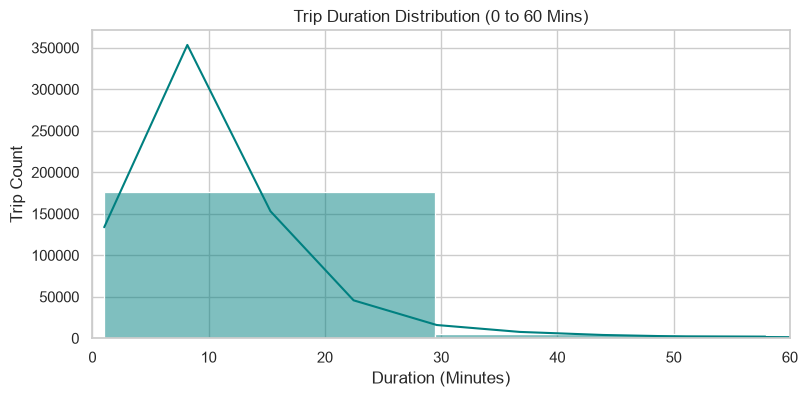

In [22]:
# 1. Distribution of Trip Duration
plt.figure(figsize=(9, 4))
sns.histplot(df_analysis['duration_min'], bins=50, color='teal', kde=True)
plt.xlim(0, 60) # Cut off extreme outliers above 60 minutes
plt.title('Trip Duration Distribution (0 to 60 Mins)')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Trip Count')
plt.show()

# Analyst Interpretation:
# "Most bike trips are short, peaking between 8 and 12 minutes. 
# This indicates that bikes are mostly used for quick city commutes or short connections."

C:\Users\Ahmed El Ashiry\AppData\Local\Temp\ipykernel_18452\1929029947.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_analysis, x='user_type', palette='Set2')


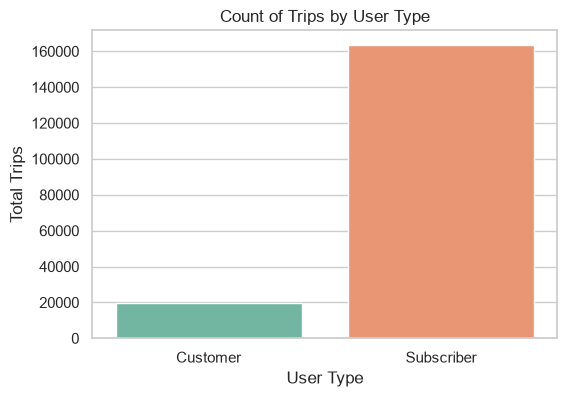

In [24]:
# 2. User Type Breakdown
plt.figure(figsize=(6, 4))
sns.countplot(data=df_analysis, x='user_type', palette='Set2')
plt.title('Count of Trips by User Type')
plt.xlabel('User Type')
plt.ylabel('Total Trips')
plt.show()

# Analyst Interpretation:
# "Subscribers generate significantly more trips than regular casual Customers.
# This proves that the platform relies heavily on repeat daily subscribers."

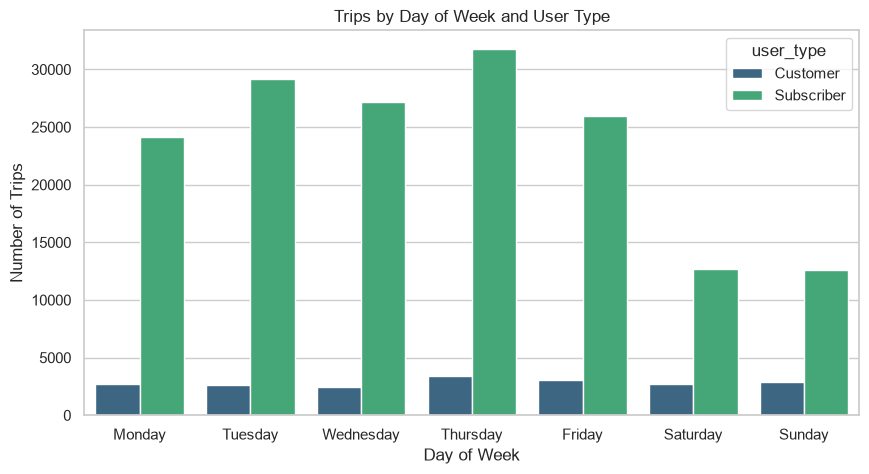

In [25]:
# 3. Trips per Day of Week by User Type
df_analysis['day_name'] = df_analysis['start_time'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
sns.countplot(data=df_analysis, x='day_name', order=days_order, hue='user_type', palette='viridis')
plt.title('Trips by Day of Week and User Type')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.show()

# Analyst Interpretation:
# "Subscriber activity peaks during weekdays (Monday-Friday), confirming work commute patterns. 
# Casual Customer usage remains steady or slightly higher on weekends for leisure rides."

C:\Users\Ahmed El Ashiry\AppData\Local\Temp\ipykernel_18452\2313465074.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_stations.values, y=top_stations.index.astype(str), palette='Blues_r')


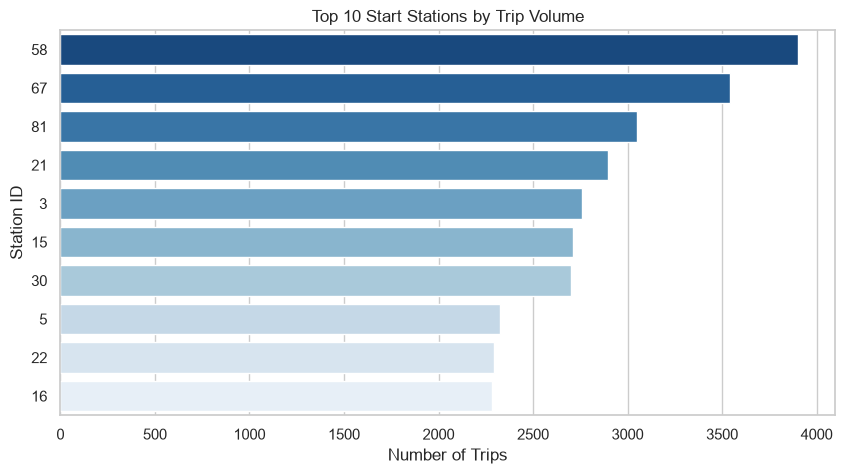

In [26]:
# 4. Top 10 Most Popular Start Stations
plt.figure(figsize=(10, 5))
top_stations = df_analysis['start_station_id'].value_counts().head(10)
sns.barplot(x=top_stations.values, y=top_stations.index.astype(str), palette='Blues_r')
plt.title('Top 10 Start Stations by Trip Volume')
plt.xlabel('Number of Trips')
plt.ylabel('Station ID')
plt.show()

# Analyst Interpretation:
# "The top start stations handle a disproportionate amount of overall traffic.
# These key locations should be prioritized for bike maintenance and dock availability."